In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



In [4]:
df =pd.read_csv(r"C:\Users\User\DA proj\Credit Risk Analytics & Loan Approval Optimization\datasets\credit_risk_dataset.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [5]:

df.rename(columns={'loan_status': 'default'},inplace=True)
df['cb_person_default_on_file']=df['cb_person_default_on_file'].apply(lambda x: 1 if x=='Y' else 0)
df.columns



Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'default', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   default                     32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  int64  
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 3.5 MB


In [7]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
default                          0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

OVERVIEW

In [8]:
print(f"Количество заявок: {len(df)}")
print(f"Средний доход: {df['person_income'].mean()}")
print(f"Медиана дохода: {df['person_income'].median()}")
print(f"Средний размер кредита: {df['loan_amnt'].mean()}")
print(f"Средняя процентная ставка по кредиту :{df['loan_int_rate'].mean()}")
print(f"Уровень дефолтов :{df['default'].mean()}")


Количество заявок: 32581
Средний доход: 66074.84846996715
Медиана дохода: 55000.0
Средний размер кредита: 9589.371105859243
Средняя процентная ставка по кредиту :11.011694892245037
Уровень дефолтов :0.21816396059052823


#Data quality section

In [9]:
#person_emp_length and loan_int_rate have missing values. We can assign them the mean value
emp_mean=df['person_emp_length'].mean()
loan_int_mean=df['loan_int_rate'].mean()
df['person_emp_length']=df['person_emp_length'].fillna(emp_mean)
df['loan_int_rate']=df['loan_int_rate'].fillna(loan_int_mean)
df.isna().sum()


person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
default                       0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [10]:
#Drop duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,default,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.790488,9593.845632,11.016733,0.218688,0.170250,0.176765,5.811297
std,6.354100,6.201558e+04,4.088378,6322.730241,3.083040,0.413363,0.106812,0.381475,4.059030
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,0.000000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,11.011695,0.000000,0.150000,0.000000,4.000000
75%,30.000000,7.921800e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,0.000000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,1.000000,30.000000


In [12]:
#There are impossible values

df=df[df['person_age']<100]
df=df[df['person_age']>df['person_emp_length']]
df=df[df['loan_percent_income']!=0]
df.shape

(32401, 12)

In Datasets contained impossible values where a persons age was 144, years of experience exceeded age and also loan percent income equals 0. These values deleted

Univariate analys

First group Applicant info consists of age, income, person_emp_length, person_home_ownership

Text(0, 0.5, 'Возраст')

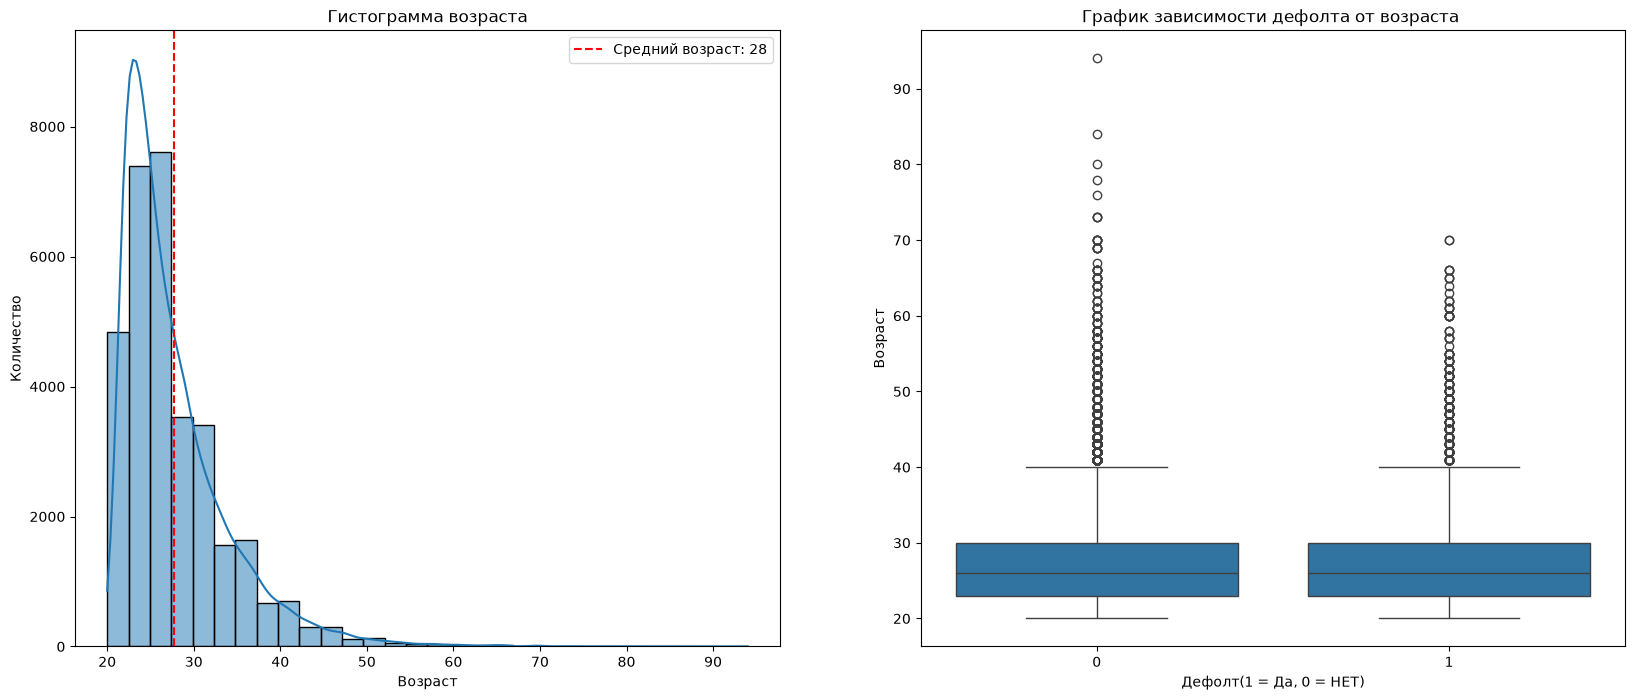

In [13]:

#Age
fig ,axes = plt.subplots(1,2,figsize=(20,8))

sns.histplot(
    data=df['person_age'],
    bins = 30,
    kde = True,
    ax=axes[0]
)
axes[0].set_title('Гистограмма возраста')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество')
axes[0].axvline(df['person_age'].mean(), color ='red', linestyle ='--', label=f'Средний возраст: {df['person_age'].mean():.0f}')
axes[0].legend()

sns.boxplot(
    x=df['default'],
    y=df['person_age'],
    ax=axes[1]
)
axes[1].set_title('График зависимости дефолта от возраста ')
axes[1].set_xlabel('Дефолт(1 = Да, 0 = НЕТ)')
axes[1].set_ylabel('Возраст')



Graph 1 shows that the majority of people taking out loans are aged between 20 and 30.
Graph 2 shows that the age does not affect on loan(since boxes are at the same height). Also graph shows that older people(age > 40) are extremely rare fail to repay a loan.

Анализ Default Rate по квинтилям дохода:


,income_quintile,min_income,max_income,total_clients,default_rate
0,Q1 (Низкий),4000,35000,6591,43.32
1,Q2,35004,49000,6508,23.54
2,Q3,49008,63000,6366,18.25
3,Q4,63096,86000,6484,14.61
4,Q5 (Высокий),86004,1782000,6452,9.18


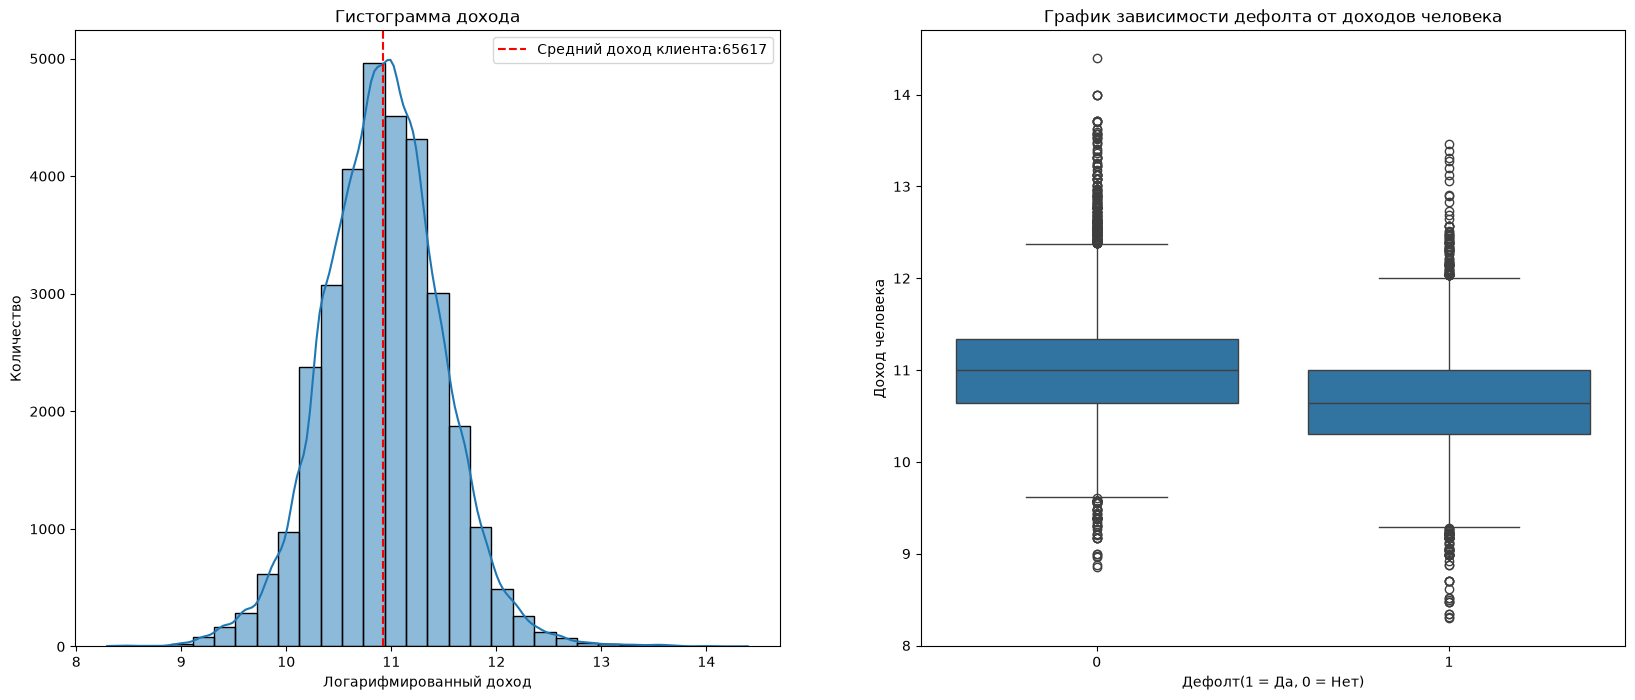

In [14]:
#Income

fig, axes =plt.subplots(1, 2, figsize=(20,8))

sns.histplot(
    data = np.log1p(df['person_income']),
    ax =axes[0],
    bins = 30,
    kde= True,
)
axes[0].set_xlabel("Логарифмированный доход")
axes[0].set_ylabel("Количество")
axes[0].set_title("Гистограмма дохода")
axes[0].axvline( np.log1p(df['person_income']).mean(),color = 'red', linestyle = '--', label=f'Средний доход клиента:{df['person_income'].mean():.0f}')
axes[0].legend()

sns.boxplot(
    x = 'default',
    y = np.log1p(df['person_income']),
    data=df,
    ax=axes[1]
)
axes[1].set_title('График зависимости дефолта от доходов человека')
axes[1].set_xlabel('Дефолт(1 = Да, 0 = Нет)')
axes[1].set_ylabel('Доход человека')

df['income_quintile'] = pd.qcut(df['person_income'], q=5, labels=['Q1 (Низкий)', 'Q2', 'Q3', 'Q4', 'Q5 (Высокий)'])
quintile_analysis = df.groupby('income_quintile').agg(
    min_income=('person_income', 'min'),
    max_income=('person_income', 'max'),
    total_clients=('default', 'count'),
    default_rate=('default', 'mean')
).reset_index()

quintile_analysis['default_rate'] = (quintile_analysis['default_rate'] * 100).round(2)

print("Анализ Default Rate по квинтилям дохода:")
display(quintile_analysis)





Table shows 5 quintiles and info.
Graph 1 shows the log distribution of people income.
Graph 2 shows that the 50% of all people has low income. Median line shares, half of peopls income lower and half larger. There are ultra rich people or outliers.
large income -> large chance to default



Text(0.5, 1.0, 'График зависимости дефолта от рабочего стажа клиента')

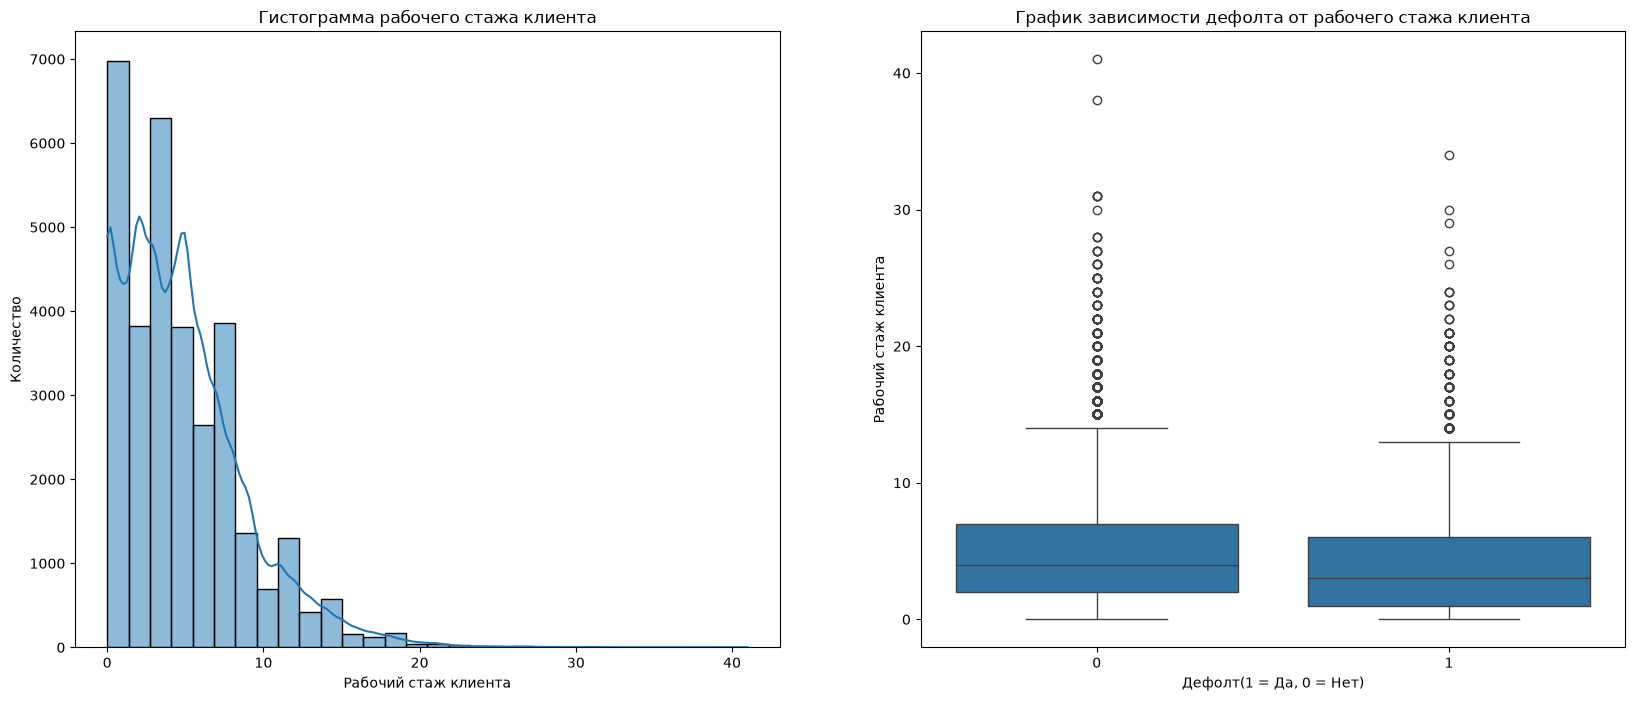

In [15]:
#person_emp_length

fig,axes = plt.subplots(1,2, figsize=(20,8))

sns.histplot(
    data = df['person_emp_length'],
    bins = 30,
    ax=axes[0],
    kde = True
)
axes[0].set_xlabel("Рабочий стаж клиента")
axes[0].set_ylabel("Количество")
axes[0].set_title("Гистограмма рабочего стажа клиента")

sns.boxplot(
    y='person_emp_length',
    x = 'default',
    data=df,
    ax=axes[1]
)
axes[1].set_xlabel("Дефолт(1 = Да, 0 = Нет)")
axes[1].set_ylabel("Рабочий стаж клиента")
axes[1].set_title("График зависимости дефолта от рабочего стажа клиента")


Graph 1 shows distribution of person emp length.
Graph 2 shows that larger person emp length -> larger chance for default

Распределение типов жилья:person_home_ownership
RENT        16372
MORTGAGE    13360
OWN          2563
OTHER         106
Name: count, dtype: int64


Text(0, 0.5, 'Количество')

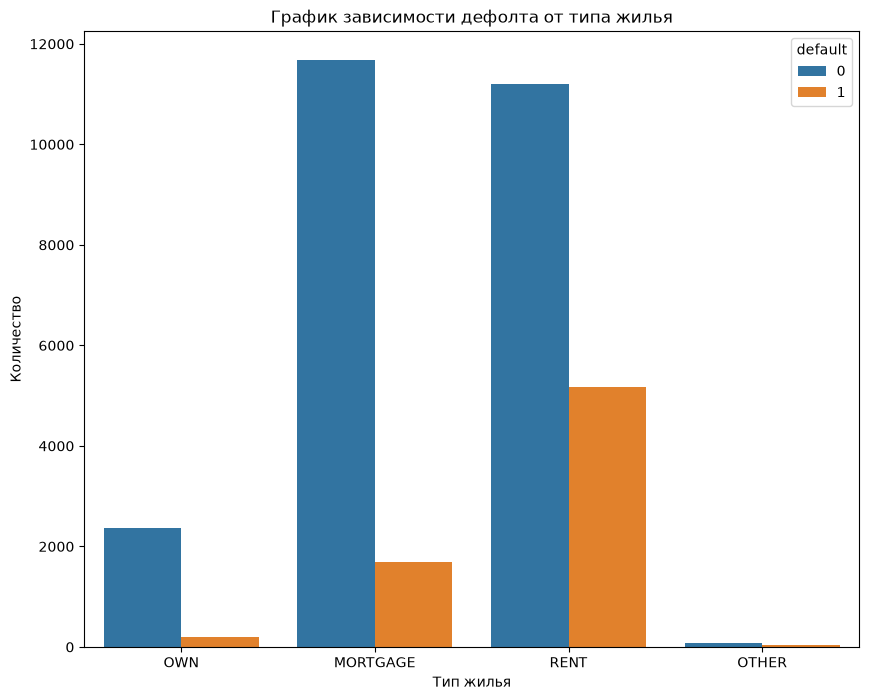

In [16]:
#person home ownership

plt.figure(figsize=(10,8))

print(f"Распределение типов жилья:{df['person_home_ownership'].value_counts()}")
sns.countplot(
    x=df['person_home_ownership'],
    hue='default',
    data=df
)
plt.title("График зависимости дефолта от типа жилья")
plt.xlabel("Тип жилья")
plt.ylabel("Количество")

This graph shows that people who rent their homes are more likely to default, when people who has mortgaged homes repay the loan.
Also the majority of dataset consists of people who rent homes and people with mortgaged homes.

Second group "Loan" consists of loan amount, interest rate, loan/income ratio, loan intent, loan grade

Таблица DR по бинам для размера кредита:


,loan_bins,total_clients,default_rate,default_rate_pct
0,"(499.999, 4400.0]",6497,0.210097,21.01
1,"(4400.0, 6800.0]",6525,0.173793,17.38
2,"(6800.0, 10000.0]",8380,0.190095,19.01
3,"(10000.0, 14500.0]",4533,0.219060,21.91
4,"(14500.0, 35000.0]",6466,0.309774,30.98


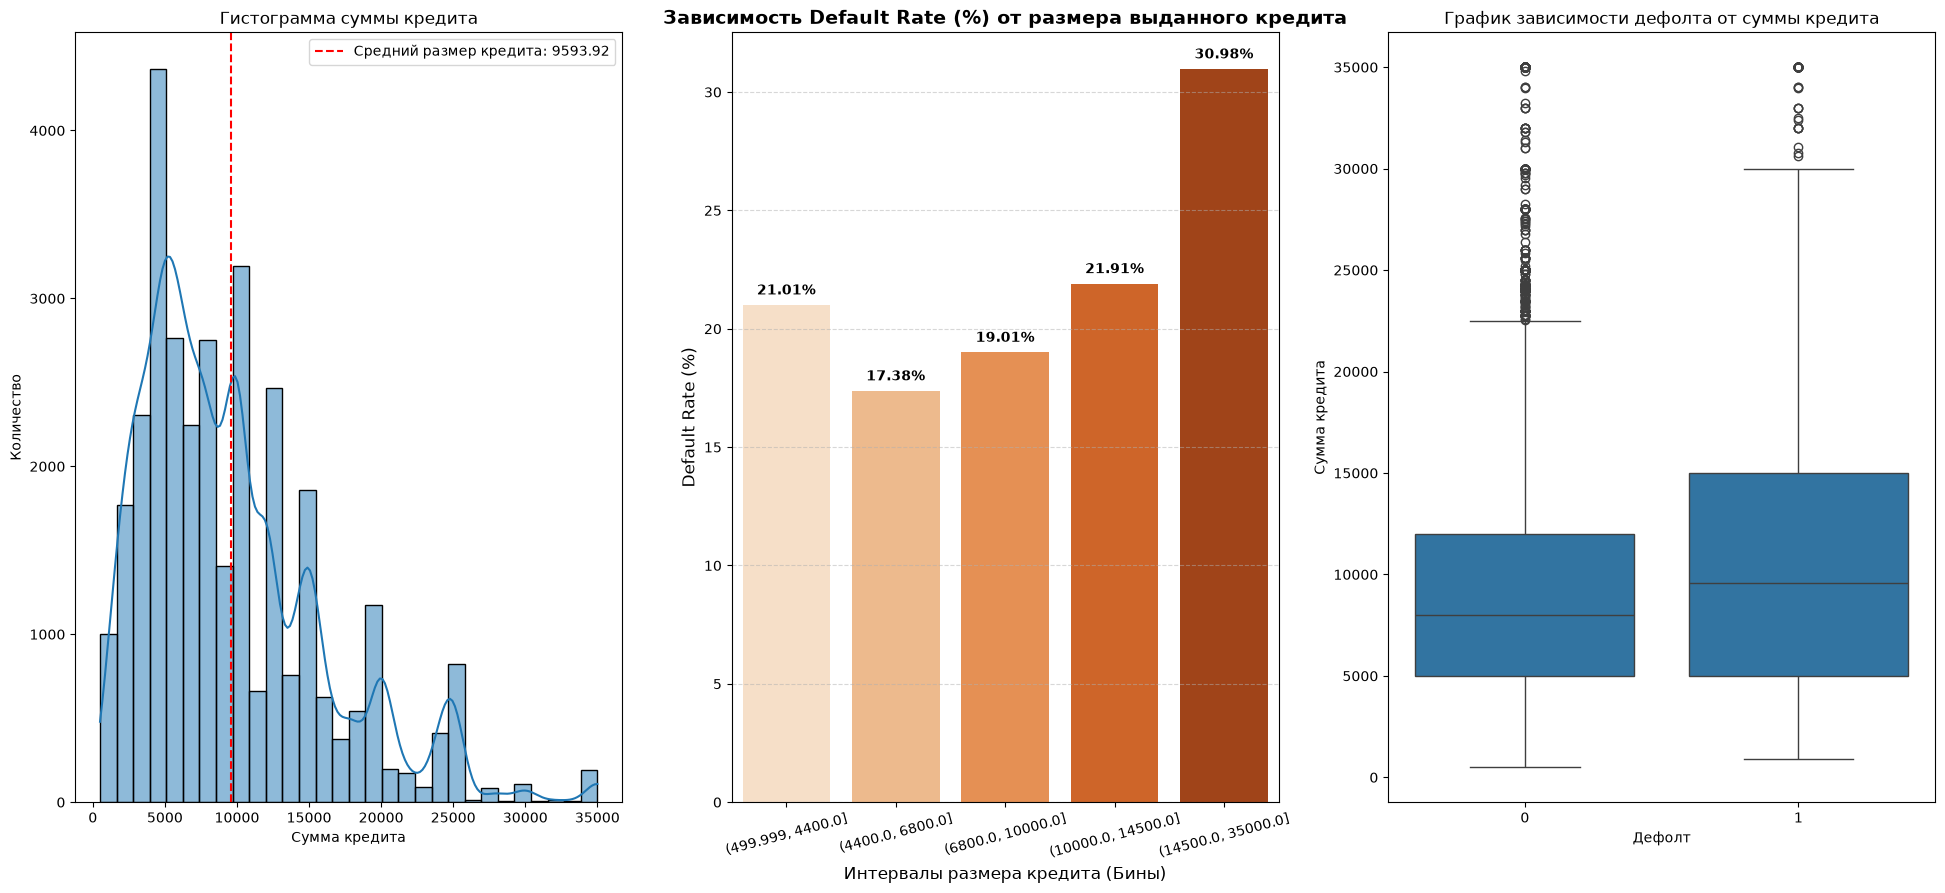

<Figure size 1200x600 with 0 Axes>

In [17]:
#1 loan_amount

fig,axes = plt.subplots(1,3,figsize=(24,10))

sns.histplot(
    data=df['loan_amnt'],
    kde = True,
    bins = 30,
    ax=axes[0]
)
axes[0].set_xlabel("Сумма кредита")
axes[0].set_ylabel("Количество")
axes[0].set_title("Гистограмма суммы кредита")
axes[0].axvline(df['loan_amnt'].mean(),color ='red', linestyle ='--', label=f"Средний размер кредита: {df['loan_amnt'].mean():.2f}")
axes[0].legend()

sns.boxplot(
    y='loan_amnt',
    x='default',
    ax=axes[2],
    data=df
)
axes[2].set_ylabel("Сумма кредита")
axes[2].set_xlabel("Дефолт")
axes[2].set_title("График зависимости дефолта от суммы кредита")


#DF by bins



df['loan_bins'] = pd.qcut(df['loan_amnt'], q=5)
dr_by_loan_size = df.groupby('loan_bins').agg(
    total_clients=('default', 'count'),
    default_rate=('default', 'mean')
).reset_index()

# Переводим Default Rate в проценты для наглядности
dr_by_loan_size['default_rate_pct'] = (dr_by_loan_size['default_rate'] * 100).round(2)

# Превращаем интервалы в строки, чтобы график красиво подписал оси
dr_by_loan_size['loan_bins'] = dr_by_loan_size['loan_bins'].astype(str)

print("Таблица DR по бинам для размера кредита:")
display(dr_by_loan_size)
# Настраиваем размер полотна
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму риска
sns.barplot(
    data=dr_by_loan_size, 
    x='loan_bins', 
    y='default_rate_pct', 
    palette='Oranges', # оранжевый цвет часто ассоциируется с риском
    ax=axes[1]
)

# Добавляем точные значения процентов над каждым столбиком
for index, row in dr_by_loan_size.iterrows():
    axes[1].text(
        index, 
        row.default_rate_pct + 0.3, 
        f"{row.default_rate_pct}%", 
        color='black', 
        ha="center", 
        va="bottom", 
        weight='bold'
    )

# Оформляем график
axes[1].set_title('Зависимость Default Rate (%) от размера выданного кредита', fontsize=14, weight='bold')
axes[1].set_xlabel('Интервалы размера кредита (Бины)', fontsize=12)
axes[1].set_ylabel('Default Rate (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation = 15)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Graph 1 shows that the distribution of loan amount.
Graph 2 shows dependence of default on loan amount. When loan amount is in (14500, 35000) deafult risk is maximum.
Graph 3 shows that the large loan_amoun -> large default risk.  In group 0  median = 8000. In grop 1 median = 10000.


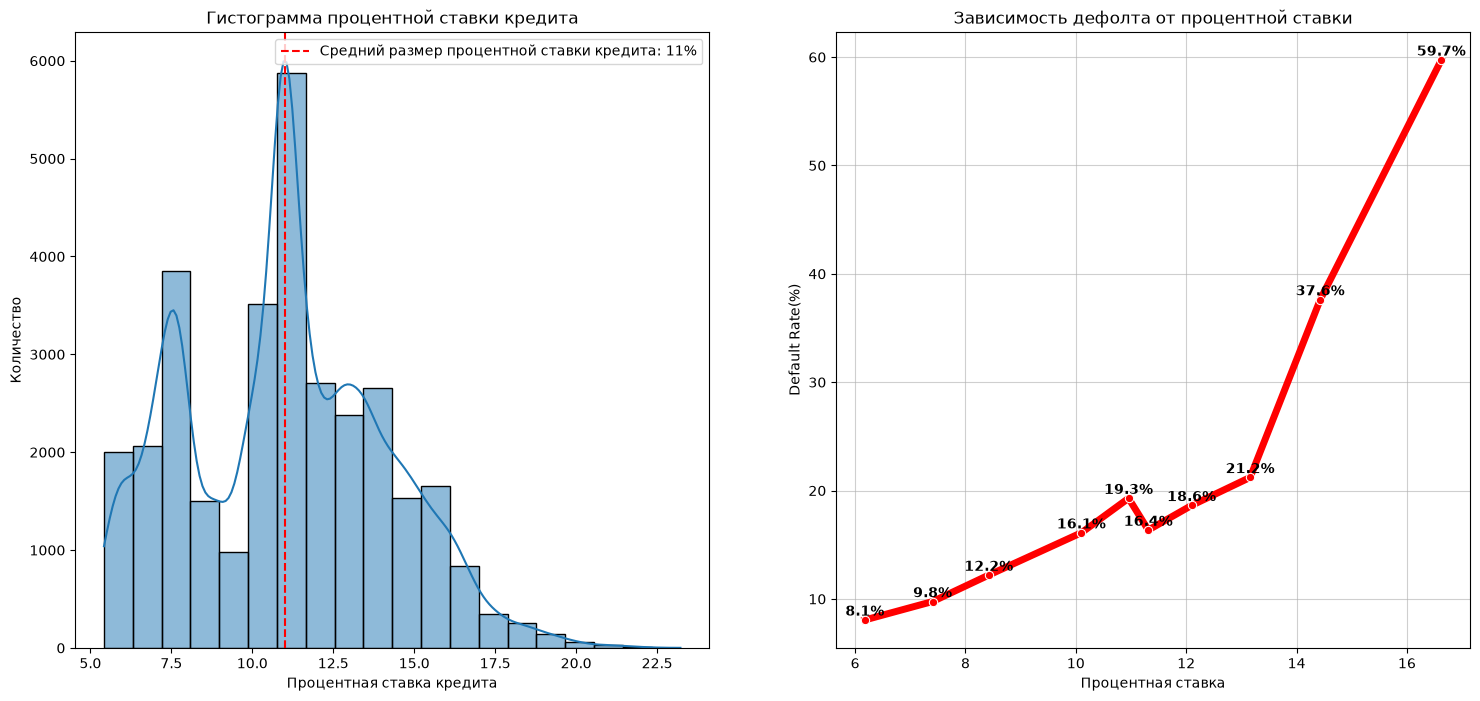

In [18]:
#2 interest_rate

fig,axes =plt.subplots(1,2, figsize=(18,8))
sns.histplot(
    data = df['loan_int_rate'],
    ax=axes[0],
    bins = 20,
    kde = True
)

axes[0].set_xlabel("Процентная ставка кредита")
axes[0].set_ylabel("Количество")
axes[0].set_title("Гистограмма процентной ставки кредита")
axes[0].axvline(df['loan_int_rate'].mean(),color ='red', linestyle ='--', label=f"Средний размер процентной ставки кредита: {df['loan_int_rate'].mean():.0f}%")
axes[0].legend()

#DF by bins

df['loan_int_bins']=pd.qcut(df['loan_int_rate'],q=10)

rate_analysis = df.groupby('loan_int_bins').agg(
    mean_rate =('loan_int_rate', 'mean'),
    default_rate = ('default', 'mean')
).reset_index()

rate_analysis['default_rate_pct']=rate_analysis['default_rate']*100

sns.lineplot(
    data=rate_analysis,
    x='mean_rate',
    y='default_rate_pct',
    marker='o',
    linewidth = 5,
    color = 'red',
    ax=axes[1]
)

for index, row in rate_analysis.iterrows():
    axes[1].text(row.mean_rate, row.default_rate_pct+0.4, s=f"{row.default_rate_pct:.1f}%", ha='center', weight ='bold')
axes[1].set_title('Зависимость дефолта от процентной ставки')
axes[1].set_xlabel('Процентная ставка')
axes[1].set_ylabel('Default Rate(%)')
axes[1].grid(True,alpha=0.6)


Graph 1 shows distribution of loan interest rate.
Graph 2 shows dependence of default on loan interest rate. Sharp increase of default rate driven by loan interest rate(>21.3%)

,loan_percent_income_quintile,mean_load,total_clients,default_rate,default_rate_pct,loan_percent_income_quintile_str
0,Q1 (Минимум),0.055562,7524,0.114700,11.47,Q1 (Минимум)
1,Q2 (Низкая),0.104641,5557,0.124708,12.47,Q2 (Низкая)
2,Q3 (Средняя),0.153086,7297,0.151706,15.17,Q3 (Средняя)
3,Q4 (Высокая),0.217172,5775,0.192208,19.22,Q4 (Высокая)
4,Q5 (Максимум),0.343596,6248,0.530570,53.06,Q5 (Максимум)


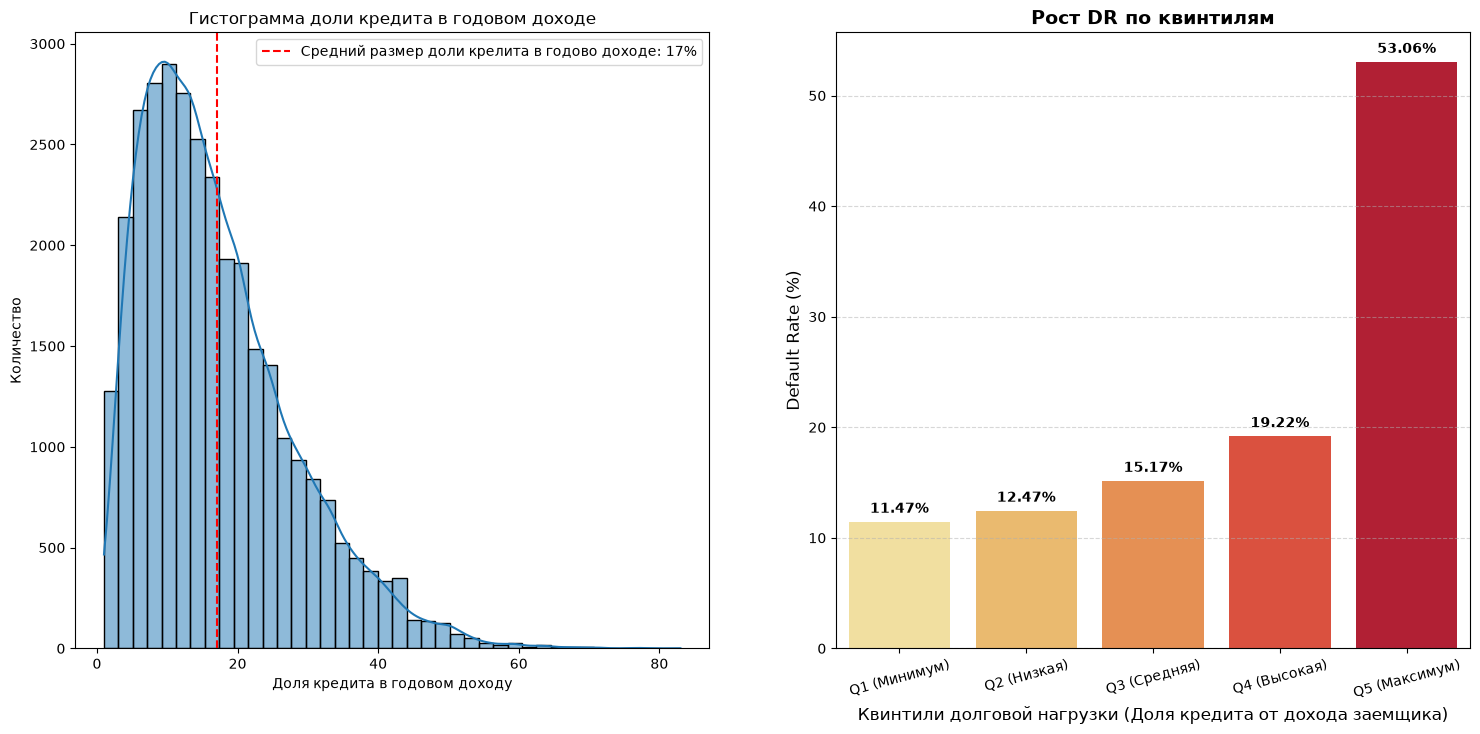

In [19]:
#3 loan percent income 

df['loan_percent_income'].describe()

fig,axes = plt.subplots(1,2, figsize=(18,8))

sns.histplot(
    data=df['loan_percent_income']*100,
    ax=axes[0],
    bins=40, 
    kde = True
)

axes[0].set_xlabel("Доля кредита в годовом доходу")
axes[0].set_ylabel("Количество")
axes[0].set_title("Гистограмма доли кредита в годовом доходе")
axes[0].axvline(df['loan_percent_income'].mean()*100,color ='red', linestyle ='--', label=f"Средний размер доли крелита в годово доходе: {df['loan_percent_income'].mean()*100:.0f}%")
axes[0].legend()

quintile_labels=['Q1 (Минимум)', 'Q2 (Низкая)', 'Q3 (Средняя)', 'Q4 (Высокая)', 'Q5 (Максимум)']

df['loan_percent_income_quintile']=pd.qcut(df['loan_percent_income'], q=5, labels=quintile_labels)

loan_percent_income_analysis=df.groupby('loan_percent_income_quintile').agg(
    mean_load =('loan_percent_income', 'mean'),
    total_clients =('default', 'count'),
    default_rate=('default', 'mean')
).reset_index()

loan_percent_income_analysis['default_rate_pct']=(loan_percent_income_analysis['default_rate']*100).round(2)
loan_percent_income_analysis['loan_percent_income_quintile_str']=loan_percent_income_analysis['loan_percent_income_quintile'].astype(str)

display(loan_percent_income_analysis)

sns.barplot(
    data=loan_percent_income_analysis,
    x='loan_percent_income_quintile_str',
    y='default_rate_pct',
    palette='YlOrRd',
    ax=axes[1]
)

for index,row in loan_percent_income_analysis.iterrows():
    axes[1].text(
        index,
        row.default_rate_pct+0.5,
        s=f"{row.default_rate_pct:.2f}%",
        color = 'black',
        ha='center',
        va='bottom',
        weight = 'bold'
    )

axes[1].set_title('Рост DR по квинтилям', fontsize=14, weight='bold')
axes[1].set_xlabel('Квинтили долговой нагрузки (Доля кредита от дохода заемщика)', fontsize=12)
axes[1].set_ylabel('Default Rate (%)', fontsize=12)
axes[1].tick_params(axis='x',rotation=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)


Graph 1 shows the distribution of loan percent income.
Graph 2 shows dependence of default on the loan percent income. 
Loan Income is strength predictor. In Q1,Q2 quintiles default rate low, but in Q5 there is high default rate.

,loan_intent,total_client,default_rate,default_rate_pct
0,VENTURE,5677,0.148670,14.87
1,EDUCATION,6409,0.172570,17.26
2,PERSONAL,5493,0.198981,19.90
3,HOMEIMPROVEMENT,3592,0.261693,26.17
4,MEDICAL,6042,0.267627,26.76
5,DEBTCONSOLIDATION,5188,0.286816,28.68


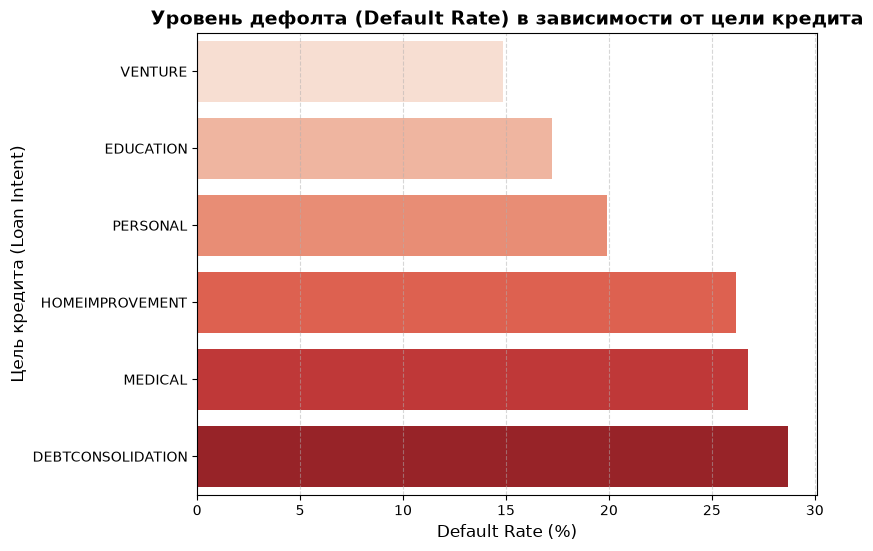

In [20]:
#4 loan intent 

df['loan_intent'].value_counts()

intent_analysis=df.groupby('loan_intent').agg(
    total_client=('default', 'count'),
    default_rate = ('default','mean')
).reset_index()

intent_analysis['default_rate_pct']=(intent_analysis['default_rate']*100).round(2)
intent_analysis=intent_analysis.sort_values('default_rate_pct').reset_index(drop=True)

display(intent_analysis)

plt.figure(figsize=(8,6))

sns.barplot(
    data=intent_analysis,
    x='default_rate_pct',
    y='loan_intent',
    palette='Reds'
)
plt.title('Уровень дефолта (Default Rate) в зависимости от цели кредита', fontsize=14, weight='bold')
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Цель кредита (Loan Intent)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)



Graph shows that the highest default risk is on Homeimprovement, medical, debtconsolidation

,loan_grade,total_clients,default_rate,default_rate_pct
0,A,10697,0.099654,9.97
1,B,10383,0.163248,16.32
2,C,6434,0.207647,20.76
3,D,3619,0.590495,59.05
4,E,963,0.644860,64.49
5,F,241,0.705394,70.54
6,G,64,0.984375,98.44


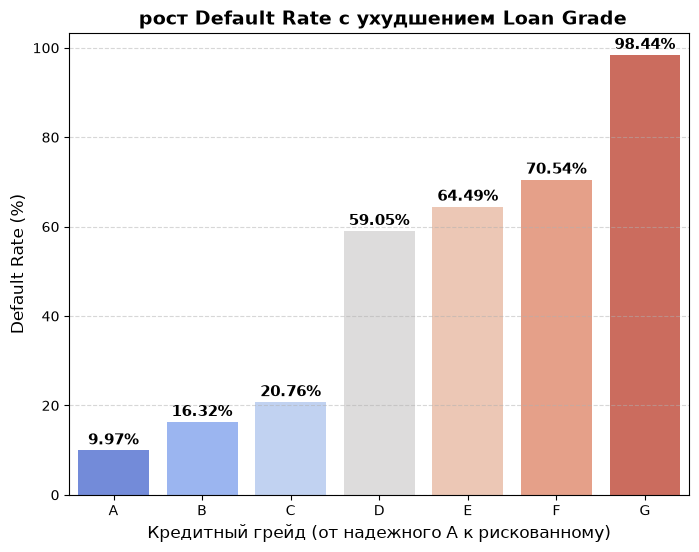

In [21]:
#5 loan grade

df['loan_grade'].value_counts()

grade_analysis=df.groupby('loan_grade').agg(
    total_clients =('default','count'),
    default_rate=('default', 'mean')
).reset_index()

grade_analysis['default_rate_pct']=(grade_analysis['default_rate']*100).round(2)
grade_analysis = grade_analysis.sort_values('loan_grade').reset_index(drop=True)

display(grade_analysis)

plt.figure(figsize=(8,6))

sns.barplot(
    data=grade_analysis,
    y='default_rate_pct',
    x='loan_grade',
    palette='coolwarm'
)

for index, row in enumerate(grade_analysis.itertuples()):
    plt.text(
        x=index,
        y=row.default_rate_pct+ 0.5,
        s=f"{row.default_rate_pct}%",
        color= 'black',
        ha='center',
        va='bottom',
        weight='bold',
        fontsize =11
    )

plt.title(' рост Default Rate с ухудшением Loan Grade', fontsize=14, weight='bold')
plt.xlabel('Кредитный грейд (от надежного A к рискованному)', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)


Graph is monotonic, so we can use loan_grade as a main predictor for model

Third Group of features is credit history consists of historical default and credit history length

,total_cliens,default_rate,default_rate_pct
cb_person_default_on_file,,,
0,26673,0.184419,18.44
1,5728,0.378666,37.87


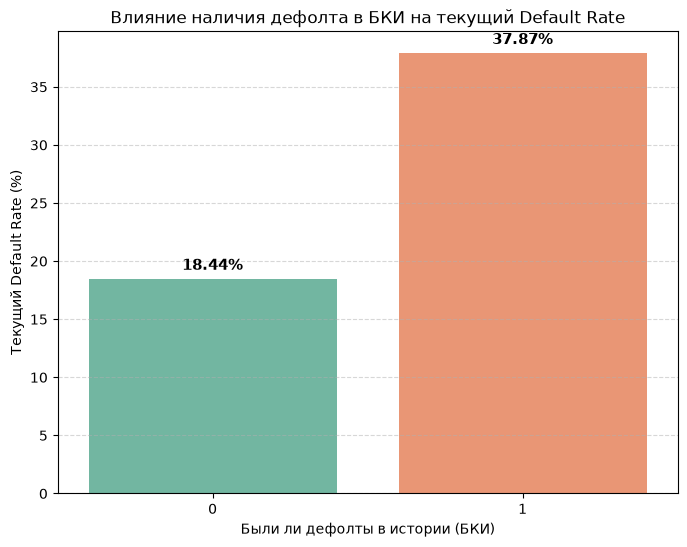

In [22]:
#1 historical default

df['cb_person_default_on_file'].value_counts()

cb_analysis = df.groupby('cb_person_default_on_file').agg(
    total_cliens = ('default', 'count'),
    default_rate = ('default','mean')
)

cb_analysis['default_rate_pct']=(cb_analysis['default_rate']*100).round(2)

display(cb_analysis)

plt.figure(figsize=(8,6))

sns.barplot(
    data=cb_analysis,
    x='cb_person_default_on_file',
    y='default_rate_pct',
    palette='Set2'
)

for i,row in cb_analysis.iterrows():
    plt.text(
        x=i,
        y=row.default_rate_pct + 0.5,
        s=f"{row.default_rate_pct}%",
        color = 'black',
        weight = 'bold',
        ha = 'center',
        va= 'bottom',
        fontsize = 11
    )
plt.title('Влияние наличия дефолта в БКИ на текущий Default Rate')
plt.xlabel('Были ли дефолты в истории (БКИ)')
plt.ylabel('Текущий Default Rate (%)')
plt.grid(axis = 'y', linestyle ='--', alpha = 0.5)

Graph shows that the cb_person_default_on_file is strong feature. People who has default in their history has default risk twice a large than the people who hasn`t default.

,hist_bins_str,mean_hist_length,total_clients,default_rate_pct
0,"(1.999, 3.0]",2.499070,11826,23.03
1,"(3.0, 4.0]",4.000000,5879,22.42
2,"(4.0, 8.0]",6.506855,7513,20.67
3,"(8.0, 30.0]",12.011416,7183,20.79


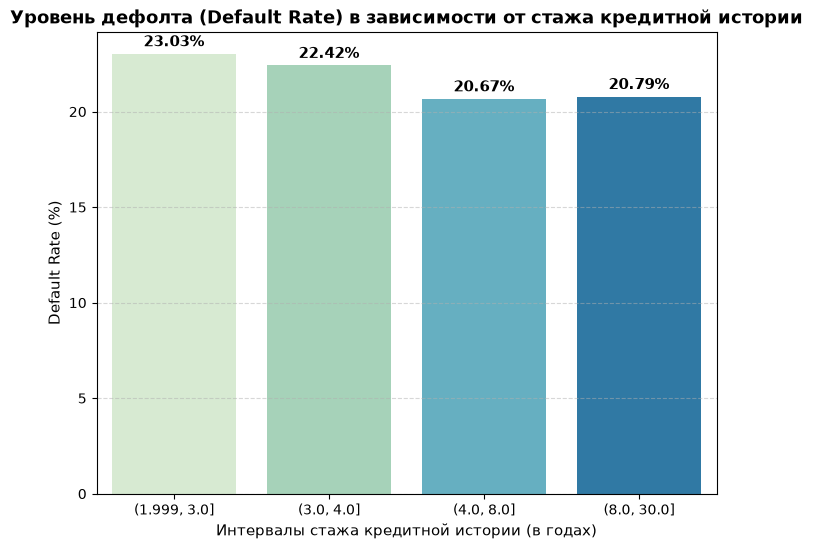

In [23]:
#2 credit history length

#df['cb_person_cred_hist_length'].value_counts()

df['hist_bins'] = pd.qcut(df['cb_person_cred_hist_length'], q=4, duplicates='drop')

hist_analysis = df.groupby('hist_bins', observed= False).agg(
    total_clients = ('default', 'count'),
    mean_hist_length = ('cb_person_cred_hist_length', 'mean'),
    default_rate= ('default', 'mean')
).reset_index()

hist_analysis['default_rate_pct']=(hist_analysis['default_rate']*100).round(2)
hist_analysis['hist_bins_str']=hist_analysis['hist_bins'].astype(str)

display(hist_analysis[['hist_bins_str', 'mean_hist_length', 'total_clients', 'default_rate_pct']])

plt.figure(figsize=(8,6))

sns.barplot(
    data= hist_analysis,
    x='hist_bins',
    y='default_rate_pct',
    palette='GnBu'
)

for i, row in hist_analysis.iterrows():
    plt.text(
        x=i,
        y=row.default_rate_pct +0.2,
        s=f"{row.default_rate_pct}%",
        color = 'black',
        ha='center',
        va='bottom',
        weight='bold',
        fontsize = 11
    )

plt.title('Уровень дефолта (Default Rate) в зависимости от стажа кредитной истории', fontsize=13, weight='bold')
plt.xlabel('Интервалы стажа кредитной истории (в годах)', fontsize=11)
plt.ylabel('Default Rate (%)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)


Graph shows that the credit history length is bad feature for prediction

RISK SEGMENTS

In [24]:

# conditions=[
#     #Low risk
#     (df['person_home_ownership']=='MORTGAGE') | (df['loan_amnt'].between(499,7000)) | (df['loan_int_rate'].between(7.5, 19)) | (df['loan_percent_income_quintile']=='Q1 (Низкая)')| (df['loan_intent'].isin(['EDUCATION', 'VENTURE'])) | (df['loan_grade'].isin(['A', 'B'])) ,
#     #High risk
#     (df['person_home_ownership']=='RENT') | (df['loan_amnt'].between(15000,35000)) | (df['loan_int_rate'].between(20.8, 59.6)) | (df['loan_percent_income_quintile']=='Q5 (Максимум)') | (df['loan_intent'].isin(['HOMEIMPROVEMENT', 'MEDICAL', 'DEBTCONSOLIDATION'])) | (df['loan_grade'].isin(['E', 'F', 'G'])) | (df['cb_person_default_on_file']==1 )
# ]

conditions = [
    # Низкий риск (Low Risk): Хороший грейд И низкая долговая нагрузка
    (df['loan_grade'].isin(['A', 'B'])) & (df['loan_percent_income'] <= 0.15),
    
    # Высокий риск (High Risk): Либо плохой грейд, либо критическая долговая нагрузка
    (df['loan_grade'].isin(['E', 'F', 'G'])) | (df['loan_percent_income'] > 0.35)
]

choices =['Low Risk',  'High Risk']

df['risk_segment'] = np.select(conditions, choices, default ='Medium Risk')

segment_analysis =df.groupby('risk_segment').agg(
    total_clients = ('default', 'count'),
    default_rate_pct = ('default', lambda x: round(x.mean()*100,2))
)

display(segment_analysis)



,total_clients,default_rate_pct
risk_segment,,
High Risk,3295,69.32
Low Risk,11704,5.20
Medium Risk,17402,24.11


<Axes: >

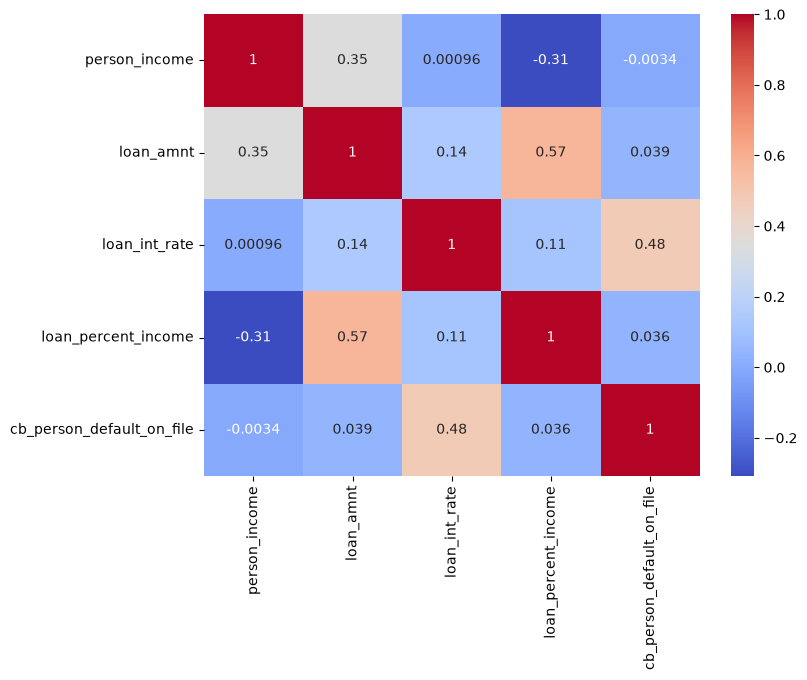

In [25]:
df.columns


features =['person_income', 'loan_amnt','loan_int_rate','loan_percent_income',
       'cb_person_default_on_file']

corr_matrix=df[features].corr()
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True
)


Feature Engineering.
Create new featuers

In [94]:
df['disposable_income']=df['person_income']-df['loan_amnt']

df['income_per_age_ratio']=df['person_income']/df['person_age']

df['cred_life_share'] = df['cb_person_cred_hist_length']/ (df['person_age'] -18 +1e-5)

df['is_new_borrower'] = (df['cb_person_cred_hist_length']<=1).astype(int)

df['risk_intencity'] = df['cb_person_default_on_file'] * df['loan_int_rate']




,disposable_income_quintile,total_clients,default_rate_pct
0,"(1449.999, 30350.0]",8104,44.06
1,"(30350.0, 46000.0]",8157,20.66
2,"(46000.0, 68000.0]",8078,14.17
3,"(68000.0, 1769975.0]",8062,8.52


Text(0, 0.5, 'Default Rate %')

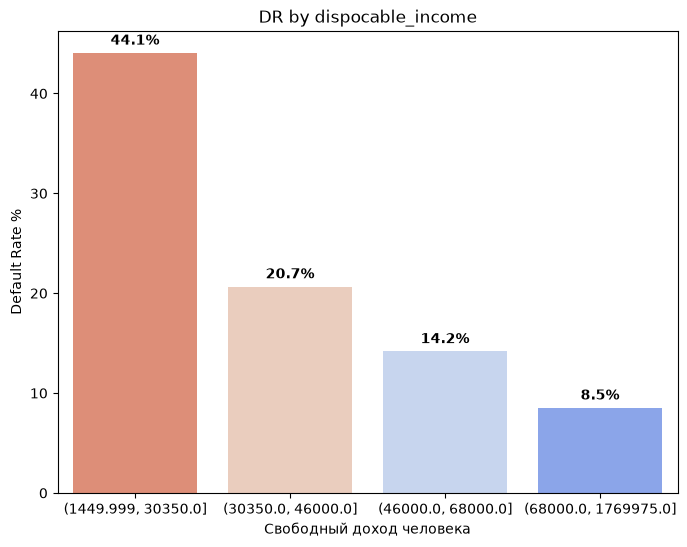

In [60]:

df['disposable_income_quintile'] = pd.qcut(df['disposable_income'], q = 4)

disposable_income_analysis = df.groupby('disposable_income_quintile').agg(
    total_clients = ('default', 'count'),
    default_rate_pct = ('default', lambda x:round(x.mean()*100, 2))
).reset_index()


display(disposable_income_analysis)


plt.figure(figsize=(8,6))

sns.barplot(
    data = disposable_income_analysis,
    x='disposable_income_quintile',
    y='default_rate_pct',
    palette='coolwarm_r'
)

for i, row in disposable_income_analysis.iterrows():
    plt.text(
        x=i,
        y=row.default_rate_pct +0.5,
        s=f"{row.default_rate_pct:.1f}%",
        ha='center',
        va='bottom',
        color = 'black',
        weight = 'bold'
    )

plt.title("DR by dispocable_income")
plt.xlabel("Свободный доход человека")
plt.ylabel("Default Rate %")

Graph shows that when deisposable_income between (1449, 30350) default risj is high.

,income_per_age_ratio_quintile,total_clients,default_rate_pct
0,"(92.225, 1410.4]",8101,38.18
1,"(1410.4, 2068.966]",8113,22.19
2,"(2068.966, 2978.261]",8089,16.95
3,"(2978.261, 37500.0]",8098,10.18


Text(0, 0.5, 'Default Rate %')

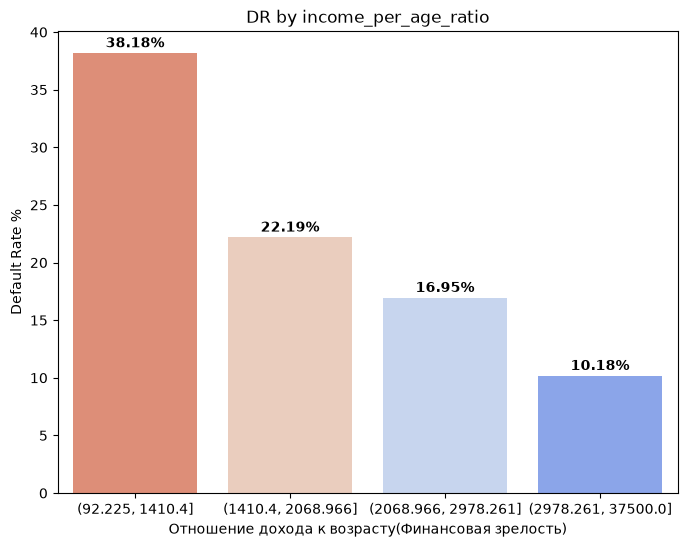

In [61]:
#income_per_age_ratio

df['income_per_age_ratio_quintile']=pd.qcut(df['income_per_age_ratio'], q=4)

ipar_analysis = df.groupby('income_per_age_ratio_quintile').agg(
    total_clients = ('default', 'count'),
    default_rate_pct = ('default', lambda x: round(x.mean()*100,2))
).reset_index()

display(ipar_analysis)

plt.figure(figsize=(8,6))

sns.barplot(
    data=ipar_analysis,
    x='income_per_age_ratio_quintile',
    y='default_rate_pct',
    palette= 'coolwarm_r'
)

for i, row in ipar_analysis.iterrows():
    plt.text(
        x= i,
        y= row.default_rate_pct +0.5,
        s=f"{row.default_rate_pct}%",
        ha = 'center',
        color= 'black',
        weight ='bold'
    )

plt.title("DR by income_per_age_ratio")
plt.xlabel("Отношение дохода к возрасту(Финансовая зрелость)")
plt.ylabel("Default Rate %")

Graph helps identify fraudsters or low-income elderly individuals. They have hidh default rate.

,cred_life_share_quintile,total_clients,default_rate_pct
0,"(0.249, 0.417]",6696,22.25
1,"(0.417, 0.5]",6295,21.32
2,"(0.5, 0.647]",6453,21.03
3,"(0.647, 0.8]",7694,21.47
4,"(0.8, 2.0]",5263,23.69


Text(0, 0.5, 'Default Rate %')

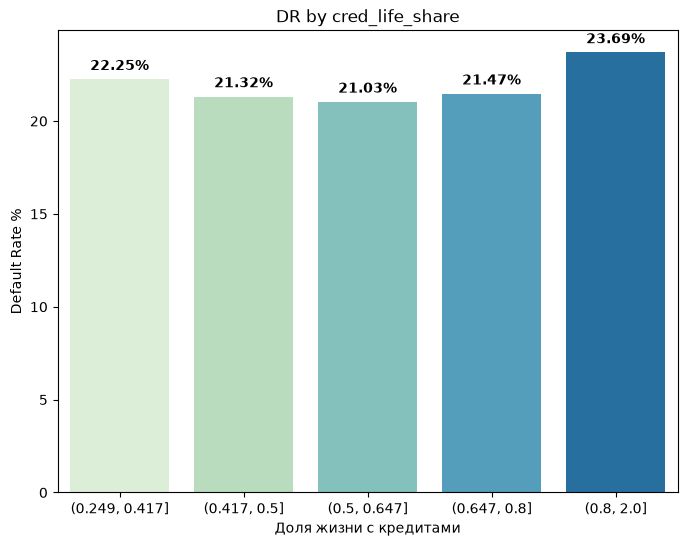

In [78]:
#cred_life_share

df['cred_life_share_quintile'] = pd.qcut(df['cred_life_share'], 5)

cred_life_analysis = df.groupby('cred_life_share_quintile').agg(
    total_clients = ('default', 'count'),
    default_rate_pct = ('default', lambda x: round(x.mean()*100,2))
).reset_index()

display(cred_life_analysis)

plt.figure(figsize=(8,6))

sns.barplot(
    data =cred_life_analysis,
    x='cred_life_share_quintile',
    y='default_rate_pct',
    palette= 'GnBu'
)

for i, row in cred_life_analysis.iterrows():
    plt.text(
        x= i,
        y= row.default_rate_pct +0.5,
        s=f"{row.default_rate_pct}%",
        ha = 'center',
        color= 'black',
        weight ='bold'
    )

plt.title("DR by cred_life_share")
plt.xlabel("Доля жизни с кредитами")
plt.ylabel("Default Rate %")

Graphs shows that the cred_life_share does not affect on default rate

In [82]:
#is_new_borrower

df['is_new_borrower'].value_counts()

is_new_borrower
0    32401
Name: count, dtype: int64

In dataset there are no new borrowers

,has_risk_intencity,total_clients,default_rate_pct
0,has risk,5728,0.378666
1,no risk,26673,0.184419


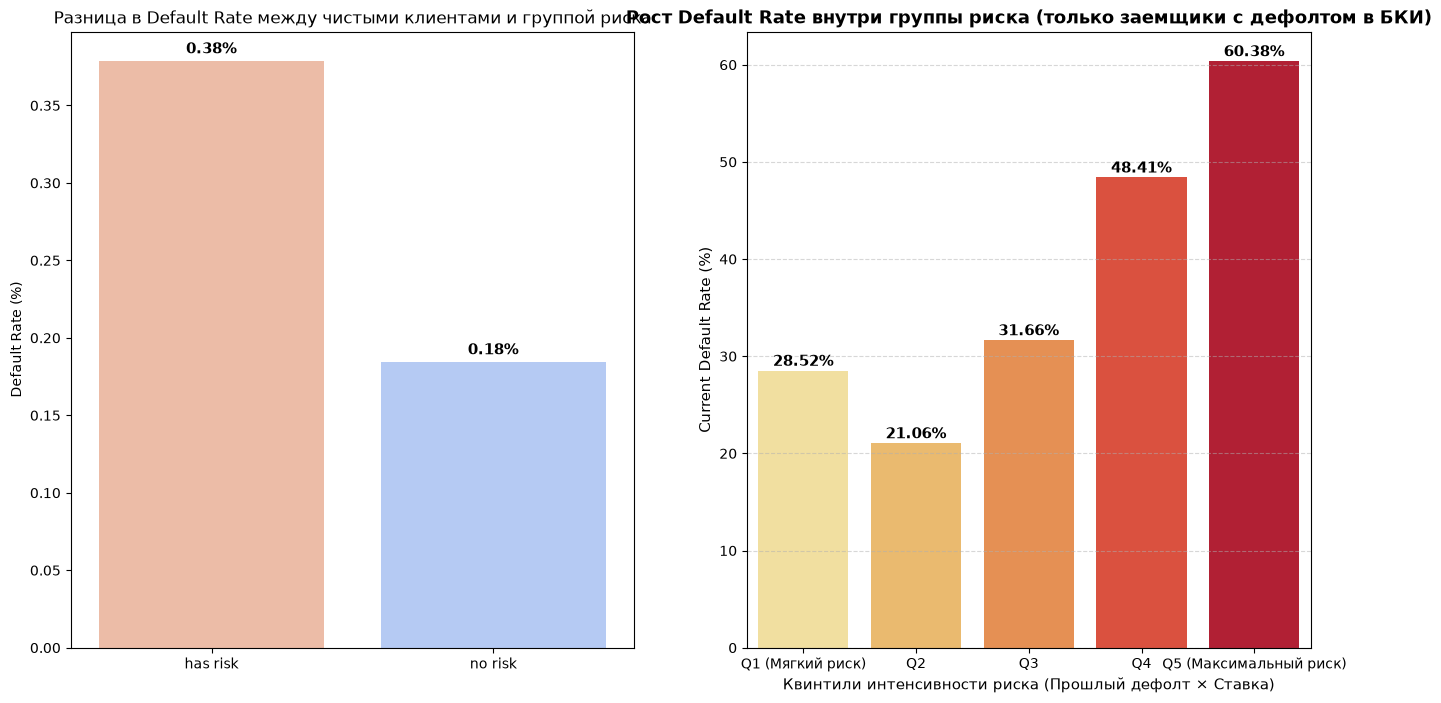

In [123]:
#risk_intencity

df['has_risk_intencity']=np.where(df['risk_intencity']>0, 'has risk', 'no risk')

risk_intencity_analysis = df.groupby('has_risk_intencity').agg(
    total_clients =('default', 'count'),
    default_rate_pct = ('default', 'mean')
).reset_index()

display(risk_intencity_analysis)

fig,axes =plt.subplots(1,2, figsize=(16,8))

sns.barplot(
    data=risk_intencity_analysis,
    x='has_risk_intencity',
    y='default_rate_pct',
    palette='coolwarm_r',
    ax = axes[0]
)

for i, row in enumerate(risk_intencity_analysis.itertuples()):
    axes[0].text(i, row.default_rate_pct +0.005 , f"{row.default_rate_pct:.2f}%", ha="center", weight='bold', fontsize=11)

axes[0].set_title('Разница в Default Rate между чистыми клиентами и группой риска')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xlabel('')

df_sub=df[df['risk_intencity']>0].copy()

labels = ['Q1 (Мягкий риск)', 'Q2', 'Q3', 'Q4', 'Q5 (Максимальный риск)']
df_sub['intensity_quintiles'] = pd.qcut(df_sub['risk_intencity'], q=5, labels=labels)

sub_analysis = df_sub.groupby('intensity_quintiles', observed=False).agg(
    mean_intensity=('risk_intencity', 'mean'),
    total_clients=('default', 'count'),
    default_rate_pct=('default', lambda x: round(x.mean() * 100, 2))
).reset_index()

sns.barplot(
    data=sub_analysis, 
    x='intensity_quintiles', 
    y='default_rate_pct', 
    palette='YlOrRd',
    ax=axes[1]
    )

for i, row in enumerate(sub_analysis.itertuples()):
    axes[1].text(i, row.default_rate_pct + 0.5, f"{row.default_rate_pct}%", ha="center", weight='bold', fontsize=11)

axes[1].set_title('Рост Default Rate внутри группы риска (только заемщики с дефолтом в БКИ)', fontsize=13, weight='bold')
axes[1].set_xlabel('Квинтили интенсивности риска (Прошлый дефолт × Ставка)', fontsize=11)
axes[1].set_ylabel('Current Default Rate (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)


Graph 1 shows that 75% people has low default risk.
Graph 2 shows that people who has default earlier, has large default risk, especially as Q5 quintile

In [132]:
df.columns

df_for_ml=df[['loan_percent_income','person_income','loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_int_rate','person_age', 'loan_amnt','default']].copy().reset_index(drop=True)

df_for_ml.to_csv('df_for_ml.csv')
df_for_ml


,loan_percent_income,person_income,loan_intent,loan_grade,cb_person_default_on_file,loan_int_rate,person_age,loan_amnt,default
0,0.10,9600,EDUCATION,B,0,11.14,21,1000,0
1,0.57,9600,MEDICAL,C,0,12.87,25,5500,1
2,0.53,65500,MEDICAL,C,0,15.23,23,35000,1
3,0.55,54400,MEDICAL,C,1,14.27,24,35000,1
4,0.25,9900,VENTURE,A,0,7.14,21,2500,1
...,...,...,...,...,...,...,...,...,...
32396,0.11,53000,PERSONAL,C,0,13.16,57,5800,0
32397,0.15,120000,PERSONAL,A,0,7.49,54,17625,0
32398,0.46,76000,HOMEIMPROVEMENT,B,0,10.99,65,35000,1
32399,0.10,150000,PERSONAL,B,0,11.48,56,15000,0


So df_for_ml is a final dataset for ML models with features which has maximum influence at default